# 1. BUSINESS PROBLEM

*Problem Statement:*  A skills gap and suboptimal utilization of Kenya's geodetic reference system (KGRS) among land sector professionals hinder the efficiency, accuracy, and interoperability of land-related operations, impacting project timelines, data quality, potentially contributing to land disputes or development challenges, and limiting the return on investment in the KGRS infrastructure.


# 2. BUSINESS UNDERSTANDING AND OBJECTIVES

## 2.1 Business Understanding:  

The KGRS is a critical infrastructure for accurate spatial referencing, and its effective utilization depends on a skilled professional workforce.  However, if professionals lack familiarity with the system, or if access to reference stations is limited or inadequate, the potential benefits of the KGRS are not fully realized. This can lead to inconsistencies in data, increased costs due to rework, and difficulties in integrating spatial information across different projects or organizations.  Furthermore, a lack of understanding regarding the KGRS within the professional landscape can hinder effective recruitment, training, and deployment of personnel with the required geodetic expertise.

## 2.2 Objectives

*1. Understanding the Professional Profile of Participants*
* Identify the demographic and professional background of land sector professionals.
* Assess the distribution of expertise across different areas of specialization.
* Evaluate the level of experience and professional practice across government and private sectors.
*2. Assessing the Current Status and Utilization of Kenya’s Geodetic Reference System*
* Evaluate professionals’ familiarity with the Kenyan Geodetic Reference Frame.
* Measure the accessibility, adequacy, and impact of geodetic reference stations on survey operations.
* Identify gaps and suggest improvements in the geodetic reference system.

# 3. DATA UNDERSTANDING, CLEANING AND PREPROCESSING

## 3.1 Data Understanding

In [47]:

import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_score, classification_report
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree        



#Read the CSV file 
df = pd.read_csv("GEODETIC_2.csv")

df.head()

,Timestamp,Username,a) Name (optional),b) Sex,c) Where do you Practice?,d) What is your Highest Education Level?,e) What is your area of specialization?,f) What is your level of Practice?,g) How many years have you practiced?,h) How would you describe yourself with respect to survey practice?,...,"c) If your answer to (b) is ""Yes"", explain the application of the gravimetric surveys you are engaged in:",d) How would you rate your frequency of use of gravity data?,e) How would you rate the adequacy of the Kenyan National Gravimetric Network?,f) How would you rate the accuracy and fit for use for the current Kenya National Gravimetric Network?,g) What recommendations would you give to help improve on the existing Kenyan National Gravimetric Network?,a) For you to effectively and efficiently practice in your area of expertise indicate areas you feel you need capacity building/enhancement\n(i) Are there knowledge areas you would wish to learn or improve on?,(ii) Are there technical skills you would wish to learn or improve on?\n,b) What support would you wish to get from your institution?,"c) At the national level, are there any specific areas you would recommend to ensure survey/professional practice is effective?\n",Unnamed: 129
0,2025/02/13 9:11:46 AM GMT+3,ongetewesly1@gmail.com,Hesbon Kebiro,Male,Private Sector,Diploma,Land Surveying,Professional - Private Sector,> 5 Years < 10 Years,Producer,...,NaN,Low,Low,Low,NaN,Land Policies;Regulations and Legislations;Int...,GNSS;Total Stations;Data Processing Applicatio...,Amass Experience,Introduction of New Technology in Surveys.,Yes
1,2025/02/13 9:15:38 AM GMT+3,wanjikunjiiru@gmail.com,Kungu Githachuri,Male,Private Sector,MSc,Civil Engineering,Professional - Private Sector,> 10 Years,End-User,...,NaN,Very Low,Neutral,Neutral,No comment,Regulations and Legislations,AI for Geospatial Practice,NaN,Strengthening of regulatory bodies in ensuring...,No
2,2025/02/13 9:24:47 AM GMT+3,alloycebrian@gmail.com,Njenga,Male,County Government,BSc,Planning,Professional - County Government,> 5 Years < 10 Years,End-User,...,NaN,Neutral,Neutral,Neutral,NaN,Land Policies;Regulations and Legislations;Int...,Data Processing Applications;AI for Geospatial...,Training,Policy Making and Harmonization of Standards& ...,No
3,2025/02/13 10:03:41 AM GMT+3,Victorbitok2000@gmail.com,Peter Lochuch,Male,Private Sector,BSc,Engineering Surveying,Professional - Private Sector,< 5 Years,Producer,...,NaN,Neutral,Neutral,Low,NaN,Regulations and Legislations,AI for Geospatial Practice,NaN,NaN,No
4,2025/02/13 10:09:11 AM GMT+3,mwovanelson7@gmail.com,Sammy Shileche,Male,County Government,BSc,Planning,Professional - County Government,> 10 Years,Producer,...,NaN,Very Low,Very Low,Very Low,NaN,Land Policies;Regulations and Legislations;Int...,Data Processing Applications;AI for Geospatial...,Payment for studies.,Accessibility to information and data.\nNo ade...,No


* Importing all the necessary libraries that are going to aid in the making of this project

* Displaying the dataframe by the use of pd.read_csv which eill fetch our data which will be displayed to ensure it is the correct data that we are going to use for this project

In [48]:
df.columns

Index(['Timestamp', 'Username', 'a) Name (optional)', 'b) Sex',
       'c) Where do you Practice?', 'd) What is your Highest Education Level?',
       'e) What is your area of specialization?',
       'f) What is your level of Practice?',
       'g) How many years have you practiced?',
       'h) How would you describe yourself with respect to survey practice?',
       ...
       'c) If your answer to (b) is "Yes", explain the application of the gravimetric surveys you are engaged in:',
       'd) How would you rate your frequency of use of gravity data?',
       'e) How would you rate the adequacy of the Kenyan National Gravimetric Network?',
       'f) How would you rate the accuracy and fit for use for the current Kenya National Gravimetric Network?',
       'g) What recommendations would you give to help improve on the existing Kenyan National Gravimetric Network?',
       'a) For you to effectively and efficiently practice in your area of expertise indicate areas you feel you need

* Establishing the type of columns we have in our data

## 3.2 Data Cleaning

### 3.2.1 Capitalizing the data

The code iterates through the columns of the DataFrame df, capitalizes the first letter of each column name, and renames the columns accordingly. The print(df) statement inside the loop will print the DataFrame's state after each column name change, which is why it will be printed multiple times.

In [49]:
for col in df.columns:
    new_col = col.capitalize()  # Capitalize the first letter
    df.rename(columns={col: new_col}, inplace=True)

    print(df)


                        Timestamp                      Username  \
0     2025/02/13 9:11:46 AM GMT+3        ongetewesly1@gmail.com   
1     2025/02/13 9:15:38 AM GMT+3       wanjikunjiiru@gmail.com   
2     2025/02/13 9:24:47 AM GMT+3        alloycebrian@gmail.com   
3    2025/02/13 10:03:41 AM GMT+3     Victorbitok2000@gmail.com   
4    2025/02/13 10:09:11 AM GMT+3        mwovanelson7@gmail.com   
..                            ...                           ...   
328   2025/02/20 5:24:15 PM GMT+3          tom.kedera@gmail.com   
329   2025/02/20 8:41:07 PM GMT+3        bkissinger98@gmail.com   
330   2025/02/21 7:34:55 AM GMT+3    nicholasmuthetha@gmail.com   
331   2025/02/22 2:55:35 PM GMT+3            kodawa78@gmail.com   
332  2025/02/22 11:44:24 PM GMT+3  ngirigacasolutions@gmail.com   

    a) Name (optional) b) Sex c) Where do you Practice?  \
0        Hesbon Kebiro   Male            Private Sector   
1    Kungu Githachuri    Male            Private Sector   
2               Nj

* Displaying how the columns will appear after the change

In [50]:
df.columns

Index(['Timestamp', 'Username', 'A) name (optional)', 'B) sex',
       'C) where do you practice?', 'D) what is your highest education level?',
       'E) what is your area of specialization?',
       'F) what is your level of practice?',
       'G) how many years have you practiced?',
       'H) how would you describe yourself with respect to survey practice?',
       ...
       'C) if your answer to (b) is "yes", explain the application of the gravimetric surveys you are engaged in:',
       'D) how would you rate your frequency of use of gravity data?',
       'E) how would you rate the adequacy of the kenyan national gravimetric network?',
       'F) how would you rate the accuracy and fit for use for the current kenya national gravimetric network?',
       'G) what recommendations would you give to help improve on the existing kenyan national gravimetric network?',
       'A) for you to effectively and efficiently practice in your area of expertise indicate areas you feel you need

* Showing the entire data with the new set of columns

In [51]:
df

,Timestamp,Username,A) name (optional),B) sex,C) where do you practice?,D) what is your highest education level?,E) what is your area of specialization?,F) what is your level of practice?,G) how many years have you practiced?,H) how would you describe yourself with respect to survey practice?,...,"C) if your answer to (b) is ""yes"", explain the application of the gravimetric surveys you are engaged in:",D) how would you rate your frequency of use of gravity data?,E) how would you rate the adequacy of the kenyan national gravimetric network?,F) how would you rate the accuracy and fit for use for the current kenya national gravimetric network?,G) what recommendations would you give to help improve on the existing kenyan national gravimetric network?,A) for you to effectively and efficiently practice in your area of expertise indicate areas you feel you need capacity building/enhancement\n(i) are there knowledge areas you would wish to learn or improve on?,(ii) are there technical skills you would wish to learn or improve on?\n,B) what support would you wish to get from your institution?,"C) at the national level, are there any specific areas you would recommend to ensure survey/professional practice is effective?\n",Unnamed: 129
0,2025/02/13 9:11:46 AM GMT+3,ongetewesly1@gmail.com,Hesbon Kebiro,Male,Private Sector,Diploma,Land Surveying,Professional - Private Sector,> 5 Years < 10 Years,Producer,...,NaN,Low,Low,Low,NaN,Land Policies;Regulations and Legislations;Int...,GNSS;Total Stations;Data Processing Applicatio...,Amass Experience,Introduction of New Technology in Surveys.,Yes
1,2025/02/13 9:15:38 AM GMT+3,wanjikunjiiru@gmail.com,Kungu Githachuri,Male,Private Sector,MSc,Civil Engineering,Professional - Private Sector,> 10 Years,End-User,...,NaN,Very Low,Neutral,Neutral,No comment,Regulations and Legislations,AI for Geospatial Practice,NaN,Strengthening of regulatory bodies in ensuring...,No
2,2025/02/13 9:24:47 AM GMT+3,alloycebrian@gmail.com,Njenga,Male,County Government,BSc,Planning,Professional - County Government,> 5 Years < 10 Years,End-User,...,NaN,Neutral,Neutral,Neutral,NaN,Land Policies;Regulations and Legislations;Int...,Data Processing Applications;AI for Geospatial...,Training,Policy Making and Harmonization of Standards& ...,No
3,2025/02/13 10:03:41 AM GMT+3,Victorbitok2000@gmail.com,Peter Lochuch,Male,Private Sector,BSc,Engineering Surveying,Professional - Private Sector,< 5 Years,Producer,...,NaN,Neutral,Neutral,Low,NaN,Regulations and Legislations,AI for Geospatial Practice,NaN,NaN,No
4,2025/02/13 10:09:11 AM GMT+3,mwovanelson7@gmail.com,Sammy Shileche,Male,County Government,BSc,Planning,Professional - County Government,> 10 Years,Producer,...,NaN,Very Low,Very Low,Very Low,NaN,Land Policies;Regulations and Legislations;Int...,Data Processing Applications;AI for Geospatial...,Payment for studies.,Accessibility to information and data.\nNo ade...,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
328,2025/02/20 5:24:15 PM GMT+3,tom.kedera@gmail.com,Tom Kedera,Male,Private Sector,BSc,Land Surveying,Professional - Private Sector,< 5 Years,Producer,...,NaN,Very Low,Neutral,Neutral,N/a,Land Policies;Regulations and Legislations,AI for Geospatial Practice,To help the upcoming professionals,National Government should embrace new technol...,NaN
329,2025/02/20 8:41:07 PM GMT+3,bkissinger98@gmail.com,Brian Kissinger,Male,Private Sector,MSc,Civil Engineering,Professional - Private Sector,< 5 Years,End-User,...,NaN,Very Low,Neutral,Neutral,NaN,Land Policies;Regulations and Legislations;Int...,GNSS;Total Stations;AI for Geospatial Practice,`Organizing trainings and workshops on the var...,-Standardization and Quality Control: Establis...,NaN
330,2025/02/21 7:34:55 AM GMT+3,nicholasmuthetha@gmail.com,nicks,Male,Private Sector,BSc,Building Surveying,Professional - Private Sector,< 5 Years,End-User,...,NaN,Very Low,Low,Low,NaN,Land Policies,GNSS;Data Processing Applications;AI for Geos

### 3.2.2 Removing all null values present in the data

It removes all columnss from the DataFrame that contain any null (missing) values. This is done to ensure that the analysis or visualization is not affected by missing data.

In [52]:
clean_df= df.dropna(axis=1)
clean_df.head()

,Timestamp,Username,B) sex,C) where do you practice?,D) what is your highest education level?,E) what is your area of specialization?,F) what is your level of practice?,G) how many years have you practiced?,H) how would you describe yourself with respect to survey practice?,"A) are you familiar with the policies, regulations and legal frameworks that influence survey/professional practice operations?",...,"A) in your field of practice, do you use levels/height data?",C) how would you rate your frequency of use of levelling benchmarks?,D) how would you rate the adequacy of the kenyan national levelling network?,E) how would you rate the accuracy and fit for use of the current kenyan levelling network?,A) are you aware of the existence of a gravimetric network?,"B) in your field of practice, do you carry out gravimetric surveys?",D) how would you rate your frequency of use of gravity data?,E) how would you rate the adequacy of the kenyan national gravimetric network?,F) how would you rate the accuracy and fit for use for the current kenya national gravimetric network?,A) for you to effectively and efficiently practice in your area of expertise indicate areas you feel you need capacity building/enhancement\n(i) are there knowledge areas you would wish to learn or improve on?
0,2025/02/13 9:11:46 AM GMT+3,ongetewesly1@gmail.com,Male,Private Sector,Diploma,Land Surveying,Professional - Private Sector,> 5 Years < 10 Years,Producer,Yes,...,Yes,Low,Low,Low,No,No,Low,Low,Low,Land Policies;Regulations and Legislations;Int...
1,2025/02/13 9:15:38 AM GMT+3,wanjikunjiiru@gmail.com,Male,Private Sector,MSc,Civil Engineering,Professional - Private Sector,> 10 Years,End-User,Yes,...,Yes,High,Neutral,Neutral,No,No,Very Low,Neutral,Neutral,Regulations and Legislations
2,2025/02/13 9:24:47 AM GMT+3,alloycebrian@gmail.com,Male,County Government,BSc,Planning,Professional - County Government,> 5 Years < 10 Years,End-User,Yes,...,Yes,Low,Neutral,Neutral,No,No,Neutral,Neutral,Neutral,Land Policies;Regulations and Legislations;Int...
3,2025/02/13 10:03:41 AM GMT+3,Victorbitok2000@gmail.com,Male,Private Sector,BSc,Engineering Surveying,Professional - Private Sector,< 5 Years,Producer,Yes,...,Yes,High,Neutral,Neutral,Yes,No,Neutral,Neutral,Low,Regulations and Legislations
4,2025/02/13 10:09:11 AM GMT+3,mwovanelson7@gmail.com,Male,County Government,BSc,Planning,Professional - County Government,> 10 Years,Producer,Yes,...,Yes,High,High,High,No,No,Very Low,Very Low,Very Low,Land Policies;Regulations and Legislations;Int...


* Viewing our new set of columns that is going to be used

In [53]:
clean_df.columns

Index(['Timestamp', 'Username', 'B) sex', 'C) where do you practice?',
       'D) what is your highest education level?',
       'E) what is your area of specialization?',
       'F) what is your level of practice?',
       'G) how many years have you practiced?',
       'H) how would you describe yourself with respect to survey practice?',
       'A) are you familiar with the policies, regulations and legal frameworks that influence survey/professional practice operations?',
       'B) how would you rate your level of understanding/interpretation of the listed policy frameworks that influence survey/professional practice operations. [sustainable development goals, 2015]',
       'B) how would you rate your level of understanding/interpretation of the listed policy frameworks that influence survey/professional practice operations. [kenya vision, 2030, 2007]',
       'B) how would you rate your level of understanding/interpretation of the listed policy frameworks that influence survey/p

## 3.3 Data Preprocessing

Data preprocessing is like preparing your data before feeding it to a machine learning model or using it for analysis. It involves tasks like converting data to the right format, and scaling or normalizing it, ensuring the data is clean, consistent, and ready for use.

* Selecting inly our relevant columns based on our business objectives that will help in the making of our model

In [54]:
geod_cols = clean_df.iloc[:, [1, 2, 3, 5, 6, 7, 9, 30, 52, 76, 77]] 
geod_cols.columns

Index(['Username', 'B) sex', 'C) where do you practice?',
       'E) what is your area of specialization?',
       'F) what is your level of practice?',
       'G) how many years have you practiced?',
       'A) are you familiar with the policies, regulations and legal frameworks that influence survey/professional practice operations?',
       'D) how would you rate your level of understanding/interpretation of the listed international frameworks that influence survey/professional practice operations [african geodetic reference frame (afref), 2006]',
       'G) how would you rate your level of reference to the listed international frameworks during your survey/professional practice [african geodetic reference frame (afref), 2006]',
       'A) how would you rate your familiarity with the kenyan geodetic reference frame?',
       'B) how would you rate your use of the geodetic reference frame during your survey/professional practice?'],
      dtype='object')

In [55]:
cada_cols = df.iloc[:, [1, 3, 93, 94, 95]] 
cada_cols.columns

Index(['Username', 'B) sex',
       '(ii) how would you rate the fitness for use of cadastral surveys in support of affordable housing?',
       '(iii) do you think the current technological approach to cadastral surveying in kenya is suitable?',
       'Explain your answer in c) (iii)'],
      dtype='object')

* Displaying only the first five datasets in our data in order to get an idea of how it looks

geod_cols.head()

* Checking whether we have any null values within our selected columns for confirmation before feeding it to the model

In [56]:
topo_cols = df.iloc[:, [1, 3, 97, 98, 99]]
topo_cols.columns

Index(['Username', 'B) sex',
       '(ii) how would you rate the fitness for use of existing topographic maps?',
       '(iii)  do you think the current technological approach to topographic mapping in kenya is suitable? (use of total stations, gnss receivers, uavs, terrestrial laser scanners, etc.,)',
       'Explain your answer in d) (iii)'],
      dtype='object')

In [57]:
poli_col = df.iloc[:, [1, 3, 56, 57, 58, 59, 60, 61, 62]]
poli_col.columns

Index(['Username', 'B) sex',
       'H) are there challenges or gaps in the listed policies that influence survey/professional practice? [kenya vision, 2030, 2007]',
       'H) are there challenges or gaps in the listed policies that influence survey/professional practice? [national land policy, 2009]',
       'H) are there challenges or gaps in the listed policies that influence survey/professional practice? [national spatial plan (2015-2045, 2017)]',
       'H) are there challenges or gaps in the listed policies that influence survey/professional practice? [national land use policy, 2017]',
       'H) are there challenges or gaps in the listed policies that influence survey/professional practice? [geospatial data sharing policy, 2021]',
       'H) are there challenges or gaps in the listed policies that influence survey/professional practice? [national urban development policy, 2016]',
       'H) are there challenges or gaps in the listed policies that influence survey/professional p

In [58]:
cada_cols.head()

,Username,B) sex,(ii) how would you rate the fitness for use of cadastral surveys in support of affordable housing?,(iii) do you think the current technological approach to cadastral surveying in kenya is suitable?,Explain your answer in c) (iii)
0,ongetewesly1@gmail.com,Male,Good,Yes,Use of new technology (GPS) for improved accur...
1,wanjikunjiiru@gmail.com,Male,NaN,Yes,The output is accurate
2,alloycebrian@gmail.com,Male,Poor,No,Neutral
3,Victorbitok2000@gmail.com,Male,Good,Yes,NaN
4,mwovanelson7@gmail.com,Male,Good,Yes,It is up to date.


In [59]:
topo_cols.head()

,Username,B) sex,(ii) how would you rate the fitness for use of existing topographic maps?,"(iii) do you think the current technological approach to topographic mapping in kenya is suitable? (use of total stations, gnss receivers, uavs, terrestrial laser scanners, etc.,)",Explain your answer in d) (iii)
0,ongetewesly1@gmail.com,Male,NaN,NaN,NaN
1,wanjikunjiiru@gmail.com,Male,Poor,Yes,They're accurate
2,alloycebrian@gmail.com,Male,Good,Yes,"From the consumer perspective, The data is re..."
3,Victorbitok2000@gmail.com,Male,Poor,Yes,NaN
4,mwovanelson7@gmail.com,Male,Neutral,Yes,It is


In [60]:
poli_col.head()

,Username,B) sex,"H) are there challenges or gaps in the listed policies that influence survey/professional practice? [kenya vision, 2030, 2007]","H) are there challenges or gaps in the listed policies that influence survey/professional practice? [national land policy, 2009]","H) are there challenges or gaps in the listed policies that influence survey/professional practice? [national spatial plan (2015-2045, 2017)]","H) are there challenges or gaps in the listed policies that influence survey/professional practice? [national land use policy, 2017]","H) are there challenges or gaps in the listed policies that influence survey/professional practice? [geospatial data sharing policy, 2021]","H) are there challenges or gaps in the listed policies that influence survey/professional practice? [national urban development policy, 2016]",H) are there challenges or gaps in the listed policies that influence survey/professional practice? [bottom up economic transformation agenda (beta]
0,ongetewesly1@gmail.com,Male,No,Yes,No,Neutral,No,No,Neutral
1,wanjikunjiiru@gmail.com,Male,Neutral,Neutral,Neutral,Neutral,Neutral,Neutral,Yes
2,alloycebrian@gmail.com,Male,No,Yes,Yes,Yes,Yes,Yes,Yes
3,Victorbitok2000@gmail.com,Male,Neutral,Neutral,Neutral,No,Neutral,No,Neutral
4,mwovanelson7@gmail.com,Male,No,No,No,No,No,No,No


In [61]:
null_counts = geod_cols.isnull().sum()
print(null_counts)

Username                                                                                                                                                                                                           0
B) sex                                                                                                                                                                                                             0
C) where do you practice?                                                                                                                                                                                          0
E) what is your area of specialization?                                                                                                                                                                            0
F) what is your level of practice?                                                                                                                  

In [62]:
null_counts = cada_cols.isnull().sum()
print(null_counts)

Username                                                                                                0
B) sex                                                                                                  0
(ii) how would you rate the fitness for use of cadastral surveys in support of affordable housing?    139
(iii) do you think the current technological approach to cadastral surveying in kenya is suitable?    150
Explain your answer in c) (iii)                                                                       208
dtype: int64


In [63]:
null_counts1 = poli_col.isnull().sum()
print(null_counts1)

Username                                                                                                                                                0
B) sex                                                                                                                                                  0
H) are there challenges or gaps in the listed policies that influence survey/professional practice? [kenya vision, 2030, 2007]                          0
H) are there challenges or gaps in the listed policies that influence survey/professional practice? [national land policy, 2009]                        0
H) are there challenges or gaps in the listed policies that influence survey/professional practice? [national spatial plan (2015-2045, 2017)]           0
H) are there challenges or gaps in the listed policies that influence survey/professional practice? [national land use policy, 2017]                    0
H) are there challenges or gaps in the listed policies that influence survey

In [64]:
cada_cols.fillna("NaN")  
cada_cols.fillna("Unknown", inplace=True)  

C:\Users\Serita\AppData\Local\Temp\ipykernel_12860\2698547756.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cada_cols.fillna("Unknown", inplace=True)


In [65]:
topo_cols.fillna("NaN")  
topo_cols.fillna("Unknown", inplace=True)  

C:\Users\Serita\AppData\Local\Temp\ipykernel_12860\2514064454.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  topo_cols.fillna("Unknown", inplace=True)


In [66]:
geod_cols.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 333 entries, 0 to 332
Data columns (total 11 columns):
 #   Column                                                                                                                                                                                                           Non-Null Count  Dtype 
---  ------                                                                                                                                                                                                           --------------  ----- 
 0   Username                                                                                                                                                                                                         333 non-null    object
 1   B) sex                                                                                                                                                                             

In [67]:
cada_cols.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 333 entries, 0 to 332
Data columns (total 5 columns):
 #   Column                                                                                              Non-Null Count  Dtype 
---  ------                                                                                              --------------  ----- 
 0   Username                                                                                            333 non-null    object
 1   B) sex                                                                                              333 non-null    object
 2   (ii) how would you rate the fitness for use of cadastral surveys in support of affordable housing?  333 non-null    object
 3   (iii) do you think the current technological approach to cadastral surveying in kenya is suitable?  333 non-null    object
 4   Explain your answer in c) (iii)                                                                     333 non-null    object


In [68]:
topo_cols.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 333 entries, 0 to 332
Data columns (total 5 columns):
 #   Column                                                                                                                                                                                Non-Null Count  Dtype 
---  ------                                                                                                                                                                                --------------  ----- 
 0   Username                                                                                                                                                                              333 non-null    object
 1   B) sex                                                                                                                                                                                333 non-null    object
 2   (ii) how would you rate the fitness for use of exis

In [69]:
poli_col.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 333 entries, 0 to 332
Data columns (total 9 columns):
 #   Column                                                                                                                                                Non-Null Count  Dtype 
---  ------                                                                                                                                                --------------  ----- 
 0   Username                                                                                                                                              333 non-null    object
 1   B) sex                                                                                                                                                333 non-null    object
 2   H) are there challenges or gaps in the listed policies that influence survey/professional practice? [kenya vision, 2030, 2007]                        333 non-null    object
 3   H

* Renaming our relevant columns to easen our work when coding and identifyingnour columns

* Relevant descriptions of our newly named columns

    Username - emails of respective samples

    Gender - the sex of respective samples

    Q1 - where do you practice?

    Q2 - what is your area of specialization?

    Q3 - what is your level of practice?

    Q4 - how many years have you practiced?

    Q5 - are you familiar with the policies, regulations and legal frameworks that influence survey/professional practice operations?

    Q6 - how would you rate your level of understanding/interpretation of the listed international frameworks that influence survey/professional practice operstions[african geodetic reference frame (afref), 2006]?

    Q7 - how would you rate yourlevel of reference to the listed international frameworks that influence survey/professional operations [african geodetic reference frame (afref), 2006]?

    Q8 - how would you rate your familiarity with the Kenyangeodetic reference frame?
    
    Q9 - how would you rate your use of the geodetic reference frame during your survey/professional practice?

In [70]:
new_labels = ['Username', 'Gender', 'Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6','Q7', 'Q8', 'Q9']
geod_cols = geod_cols.set_axis(new_labels, axis='columns') 

print(geod_cols)

                         Username Gender                 Q1  \
0          ongetewesly1@gmail.com   Male     Private Sector   
1         wanjikunjiiru@gmail.com   Male     Private Sector   
2          alloycebrian@gmail.com   Male  County Government   
3       Victorbitok2000@gmail.com   Male     Private Sector   
4          mwovanelson7@gmail.com   Male  County Government   
..                            ...    ...                ...   
328          tom.kedera@gmail.com   Male     Private Sector   
329        bkissinger98@gmail.com   Male     Private Sector   
330    nicholasmuthetha@gmail.com   Male     Private Sector   
331            kodawa78@gmail.com   Male     Private Sector   
332  ngirigacasolutions@gmail.com   Male     Private Sector   

                                            Q2  \
0                               Land Surveying   
1                            Civil Engineering   
2                                     Planning   
3                        Engineering Survey

In [71]:
new_labels1 = ['Username', 'Gender', 'QC1', 'QC2', 'QC3']
cada_cols = cada_cols.set_axis(new_labels1, axis='columns') 

print(cada_cols)

                         Username Gender        QC1      QC2  \
0          ongetewesly1@gmail.com   Male       Good      Yes   
1         wanjikunjiiru@gmail.com   Male    Unknown      Yes   
2          alloycebrian@gmail.com   Male       Poor       No   
3       Victorbitok2000@gmail.com   Male       Good      Yes   
4          mwovanelson7@gmail.com   Male       Good      Yes   
..                            ...    ...        ...      ...   
328          tom.kedera@gmail.com   Male       Poor      Yes   
329        bkissinger98@gmail.com   Male    Unknown  Unknown   
330    nicholasmuthetha@gmail.com   Male       Good       No   
331            kodawa78@gmail.com   Male    Neutral  Unknown   
332  ngirigacasolutions@gmail.com   Male  Very Poor       No   

                                                   QC3  
0    Use of new technology (GPS) for improved accur...  
1                               The output is accurate  
2                                             Neutral   
3  

In [72]:
new_labels2 = ['Username', 'Gender', 'QT1', 'QT2', 'QT3']
topo_cols = topo_cols.set_axis(new_labels2, axis='columns') 

print(topo_cols)

                         Username Gender        QT1      QT2  \
0          ongetewesly1@gmail.com   Male    Unknown  Unknown   
1         wanjikunjiiru@gmail.com   Male       Poor      Yes   
2          alloycebrian@gmail.com   Male       Good      Yes   
3       Victorbitok2000@gmail.com   Male       Poor      Yes   
4          mwovanelson7@gmail.com   Male    Neutral      Yes   
..                            ...    ...        ...      ...   
328          tom.kedera@gmail.com   Male  Very Poor      Yes   
329        bkissinger98@gmail.com   Male    Unknown  Unknown   
330    nicholasmuthetha@gmail.com   Male  Very Poor      Yes   
331            kodawa78@gmail.com   Male       Good      Yes   
332  ngirigacasolutions@gmail.com   Male       Poor      Yes   

                                                   QT3  
0                                              Unknown  
1                                    They're accurate   
2    From the consumer perspective,  The data is re...  
3  

In [73]:
new_labels3 = ['Username', 'Gender', 'QP1', 'QP2', 'QP3', 'QP4', 'QP5', 'QP6', 'QP7']
poli_cols = poli_col.set_axis(new_labels3, axis='columns') 

print(poli_cols)

                         Username Gender      QP1      QP2      QP3      QP4  \
0          ongetewesly1@gmail.com   Male       No      Yes       No  Neutral   
1         wanjikunjiiru@gmail.com   Male  Neutral  Neutral  Neutral  Neutral   
2          alloycebrian@gmail.com   Male       No      Yes      Yes      Yes   
3       Victorbitok2000@gmail.com   Male  Neutral  Neutral  Neutral       No   
4          mwovanelson7@gmail.com   Male       No       No       No       No   
..                            ...    ...      ...      ...      ...      ...   
328          tom.kedera@gmail.com   Male      Yes      Yes  Neutral      Yes   
329        bkissinger98@gmail.com   Male      Yes      Yes      Yes      Yes   
330    nicholasmuthetha@gmail.com   Male       No       No       No       No   
331            kodawa78@gmail.com   Male       No      Yes       No       No   
332  ngirigacasolutions@gmail.com   Male      Yes      Yes      Yes      Yes   

         QP5      QP6      QP7  
0     

# 4. MODEL CREATION

## 4.0.1 Creating the necessary categoricals 

Creating categorical variables (if they aren't already in your data) allows you to represent qualitative data (like colors, types, or categories) in a way that machine learning models can understand and use.  Essentially, it converts text or descriptive labels into numerical form, enabling the model to learn patterns and relationships based on those categories.

In [74]:
categoricals = geod_cols

for col in categoricals:
    print(geod_cols[col].value_counts(), "\n")

Username
ongetewesly1@gmail.com          25
lizmwawasi@gmail.com            23
barnabassure04@gmail.com        23
kawirasharon996@gmail.com       21
wanjikunjiiru@gmail.com         20
                                ..
alfredobaga3@gmail.com           1
r.itambo@kenha.co.ke             1
ochyps@gmail.com                 1
sharonsanj90@gmail.com           1
ngirigacasolutions@gmail.com     1
Name: count, Length: 70, dtype: int64 

Gender
Male      245
Female     88
Name: count, dtype: int64 

Q1
Private Sector         191
National Government     95
County Government       47
Name: count, dtype: int64 

Q2
Land Surveying                               69
Geospatial Information Management Systems    46
Planning                                     33
Valuation                                    25
Engineering Surveying                        24
Civil Engineering                            21
Land Administration Management               20
Architecture                                 18
Prop

In [75]:
categoricals1 = cada_cols

for col1 in categoricals1:
    print(cada_cols[col1].value_counts(), "\n")

Username
ongetewesly1@gmail.com          25
lizmwawasi@gmail.com            23
barnabassure04@gmail.com        23
kawirasharon996@gmail.com       21
wanjikunjiiru@gmail.com         20
                                ..
alfredobaga3@gmail.com           1
r.itambo@kenha.co.ke             1
ochyps@gmail.com                 1
sharonsanj90@gmail.com           1
ngirigacasolutions@gmail.com     1
Name: count, Length: 70, dtype: int64 

Gender
Male      245
Female     88
Name: count, dtype: int64 

QC1
Unknown      139
Good          82
Neutral       63
Poor          23
Very Good     17
Very Poor      9
Name: count, dtype: int64 

QC2
Unknown    150
Yes        118
No          65
Name: count, dtype: int64 

QC3
Unknown                                                                                                     208
Neutral                                                                                                       2
Use of new technology (GPS) for improved accuracy, rather than t

In [76]:
categoricals2 = topo_cols

for col2 in categoricals2:
    print(topo_cols[col2].value_counts(), "\n")

Username
ongetewesly1@gmail.com          25
lizmwawasi@gmail.com            23
barnabassure04@gmail.com        23
kawirasharon996@gmail.com       21
wanjikunjiiru@gmail.com         20
                                ..
alfredobaga3@gmail.com           1
r.itambo@kenha.co.ke             1
ochyps@gmail.com                 1
sharonsanj90@gmail.com           1
ngirigacasolutions@gmail.com     1
Name: count, Length: 70, dtype: int64 

Gender
Male      245
Female     88
Name: count, dtype: int64 

QT1
Unknown      147
Neutral       73
Good          58
Poor          42
Very Poor      9
Very Good      4
Name: count, dtype: int64 

QT2
Yes        163
Unknown    154
No          16
Name: count, dtype: int64 

QT3
Unknown                                                                                                                            224
Improved accuracy                                                                                                                    2
Cover vast regions

In [77]:
categoricals3 = poli_cols

for col3 in categoricals3:
    print(poli_cols[col3].value_counts(), "\n")

Username
ongetewesly1@gmail.com          25
lizmwawasi@gmail.com            23
barnabassure04@gmail.com        23
kawirasharon996@gmail.com       21
wanjikunjiiru@gmail.com         20
                                ..
alfredobaga3@gmail.com           1
r.itambo@kenha.co.ke             1
ochyps@gmail.com                 1
sharonsanj90@gmail.com           1
ngirigacasolutions@gmail.com     1
Name: count, Length: 70, dtype: int64 

Gender
Male      245
Female     88
Name: count, dtype: int64 

QP1
Neutral    127
No         114
Yes         92
Name: count, dtype: int64 

QP2
Neutral    137
No         103
Yes         93
Name: count, dtype: int64 

QP3
Neutral    163
No          99
Yes         71
Name: count, dtype: int64 

QP4
Neutral    135
No         103
Yes         95
Name: count, dtype: int64 

QP5
Neutral    187
No          82
Yes         64
Name: count, dtype: int64 

QP6
Neutral    150
No          96
Yes         87
Name: count, dtype: int64 

QP7
Neutral    179
Yes         82
No     

## 4.1 Bar Chart data representation

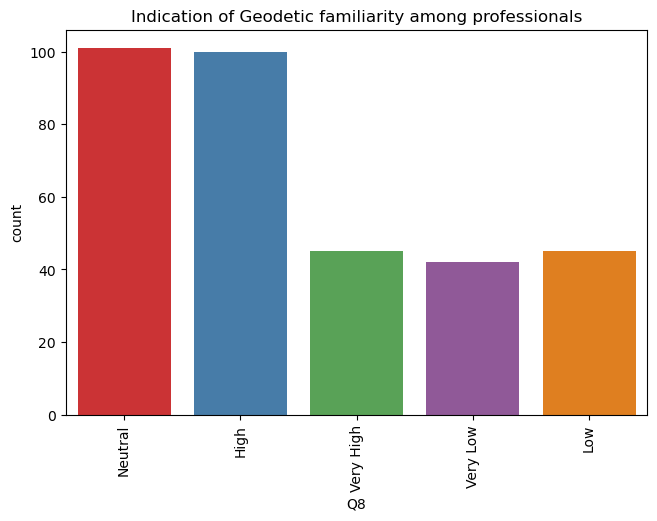

In [78]:
plt.figure(figsize=(7.5, 5))  
sns.countplot(x=geod_cols["Q8"], hue=geod_cols["Q8"], palette="Set1")
plt.xticks(rotation=90)
plt.title("Indication of Geodetic familiarity among professionals")
plt.show()

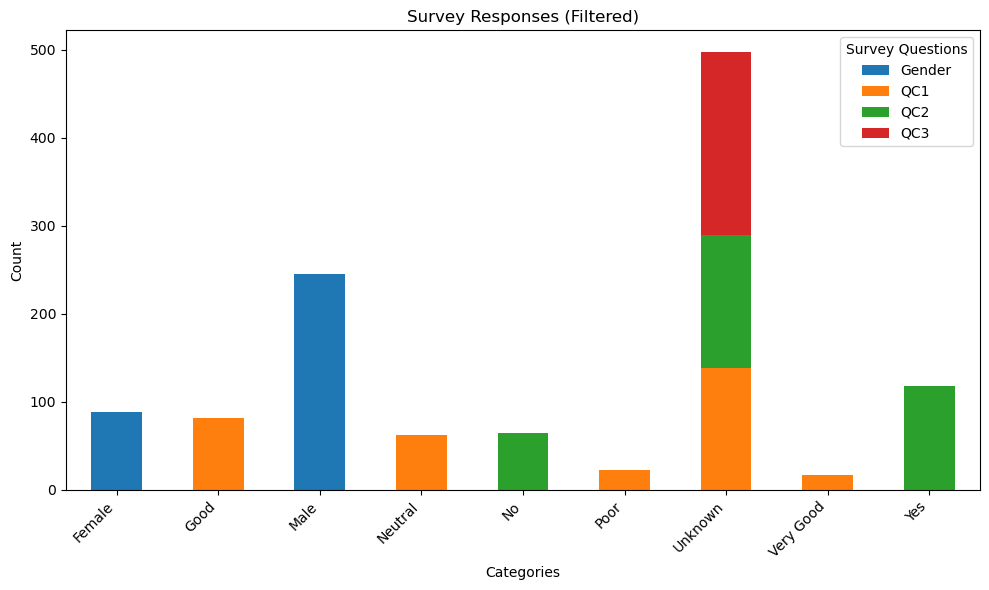

In [79]:
# Data from your provided text (same as before)
gender_data = {'Male': 245, 'Female': 88}
qc1_data = {'Unknown': 139, 'Good': 82, 'Neutral': 63, 'Very Good': 17, 'Poor': 23, 'Very Poor': 9}
qc2_data = {'Unknown': 150, 'Yes': 118, 'No': 65}
qc3_data = {'Unknown': 208, 'Neutral': 2, 'Use of new technology (GPS) for improved accuracy, rather than traditional equipment like tape measures.': 1, 'THE USE OD EMERGING TECHNOLOGIES IN SURVEY WORK IS BIG STEP TOWARD MAKING SURVEY WORKS EASIER': 1, 'The current approach ensures that outputs are authenticated and checked, which allows for survey work done by one person to be used by other surveyors': 1, 'It is gradually headed in the right direction': 1, 'The cadastral system in Kenya remains largely manual, with land records maintained in paper format and most operations conducted manually. This lack of computerization and decentralization leads to inefficiencies, delays, and difficulties in accessing and updating land information.': 1, 'Advancement in technology/equipment with high accuracy levels': 1, 'Following the Survey Act, Land. Act 2012 and Registration Act, the current technology is serving well, but technology should be improved to enhance high precisions and accuracies.': 1, "I don't believe the current technological approach to cadastral surveying is suitable. While some progress has been made, there is still an over-reliance on oudated methods in some areas.": 1}

# Convert to Series
gender = pd.Series(gender_data)
qc1 = pd.Series(qc1_data)
qc2 = pd.Series(qc2_data)
qc3 = pd.Series(qc3_data)

# Create DataFrame
df = pd.DataFrame({'Gender': gender, 'QC1': qc1, 'QC2': qc2, 'QC3': qc3}).fillna(0)

# Threshold for "negligible" results (adjust as needed)
threshold = 10  # Example: Remove categories with counts less than 10

# Filter out negligible results
df_filtered = df.copy()  # Create a copy to avoid modifying the original DataFrame
for col in df_filtered.columns:
    df_filtered[col] = df_filtered[col][df_filtered[col] >= threshold]  # Filter each column
df_filtered = df_filtered.dropna(how='all') #drops rows where all values are NaN

# Plotting the filtered stacked bar chart
ax = df_filtered.plot(kind='bar', stacked=True, figsize=(10, 6))

plt.title('Survey Responses (Filtered)')
plt.xlabel('Categories')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Survey Questions')
plt.tight_layout()
plt.show()

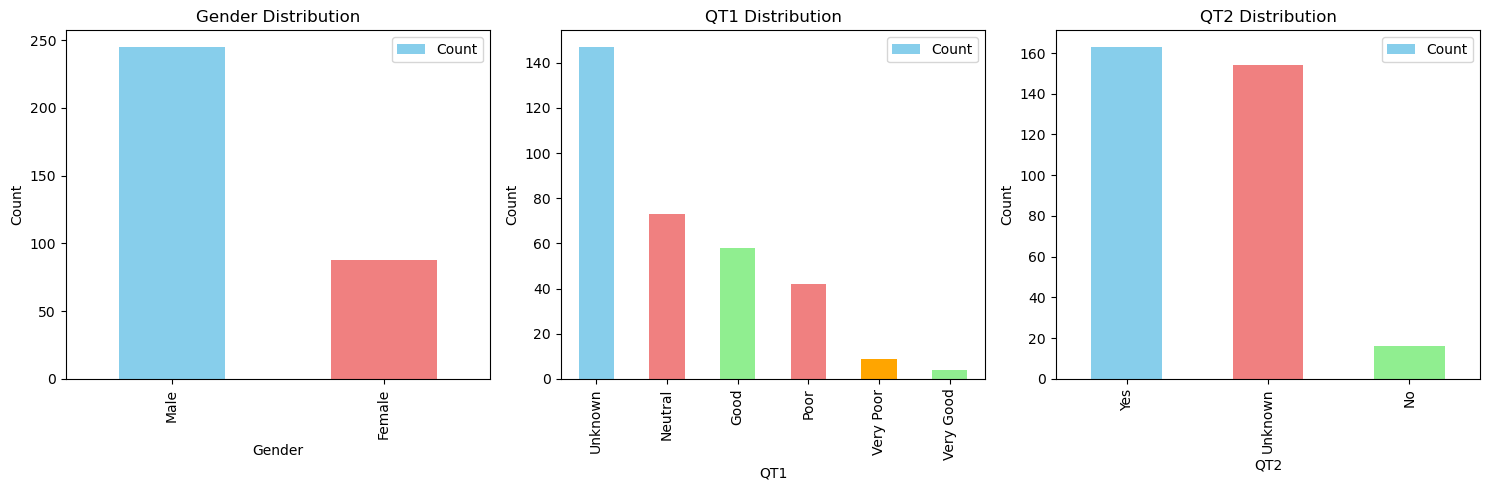

In [80]:
# Data from your provided information
gender_data = {'Male': 245, 'Female': 88}
qt1_data = {'Unknown': 147, 'Neutral': 73, 'Good': 58, 'Poor': 42, 'Very Poor': 9, 'Very Good': 4}
qt2_data = {'Yes': 163, 'Unknown': 154, 'No': 16}


# Create DataFrames for plotting
gender_df = pd.DataFrame(list(gender_data.items()), columns=['Gender', 'Count'])
qt1_df = pd.DataFrame(list(qt1_data.items()), columns=['QT1', 'Count'])
qt2_df = pd.DataFrame(list(qt2_data.items()), columns=['QT2', 'Count'])



# Plotting
fig, axes = plt.subplots(1, 3, figsize=(15, 5))  # 1 row, 3 columns of subplots

# Gender
gender_df.plot(x='Gender', y='Count', kind='bar', ax=axes[0], color=['skyblue', 'lightcoral'])
axes[0].set_title('Gender Distribution')
axes[0].set_ylabel('Count')


# QT1
qt1_df.plot(x='QT1', y='Count', kind='bar', ax=axes[1], color=['skyblue', 'lightcoral', 'lightgreen', 'lightcoral', 'orange', 'lightgreen']) #Added more colors
axes[1].set_title('QT1 Distribution')
axes[1].set_ylabel('Count')

# QT2
qt2_df.plot(x='QT2', y='Count', kind='bar', ax=axes[2], color=['skyblue', 'lightcoral', 'lightgreen'])
axes[2].set_title('QT2 Distribution')
axes[2].set_ylabel('Count')

plt.tight_layout() # Adjusts subplot params so that subplots fit in to the figure area.
plt.show()

### 4.1.1 Conclusions of the bar chart
#### 1. Understanding the Professional Profile of Participants:

* Diverse Expertise Represented: The survey captures responses from a range of land sector professionals, including Land Surveyors, Geospatial Information Management specialists, Planners, and others, demonstrating a diversity of expertise relevant to geodetic reference systems. (Connects to: Identify the demographic and professional background...)
* Private Sector Predominance: The significant representation from the private sector (as evidenced by the heatmap) suggests a strong engagement of this sector with geodetic reference systems. (Connects to: Evaluate the level of experience and professional practice across government and private sectors.)
* Varying Levels of Experience: The distribution of familiarity levels (from "Very Low" to "Very High") likely reflects a range of experience and engagement with geodetic reference systems across the professional spectrum. Further analysis could explore correlations between profession and familiarity. (Connects to: Assess the distribution of expertise across different areas of specialization.)
#### 2. Assessing the Current Status and Utilization of Kenya’s Geodetic Reference System:

* Moderate Familiarity with Geodetic Reference Frame: While "Neutral" and "High" familiarity are prevalent, the presence of respondents in the "Low" and "Very Low" categories indicates a need for improved awareness and training on the Kenyan Geodetic Reference Frame. (Connects to: Evaluate professionals’ familiarity with the Kenyan Geodetic Reference Frame.)
* Potential Gaps in Utilization: The data suggests potential gaps in the consistent and effective utilization of the geodetic reference system, particularly among those reporting lower familiarity. Further investigation is needed to understand the barriers to access and effective use. (Connects to: Measure the accessibility, adequacy, and impact of geodetic reference stations...)
* Targeted Interventions Needed: The varying levels of familiarity across professions highlight the need for targeted interventions and training programs tailored to the specific needs of different professional groups. (Connects to: Identify gaps and suggest improvements in the geodetic reference system.)

#### Overall Summary (Combined):

The survey reveals a diverse professional landscape engaged with geodetic reference systems, with the private sector being a prominent participant.  While a substantial portion of professionals report moderate to high familiarity, the presence of lower familiarity levels indicates a potential need for improved training and access to resources related to the Kenyan Geodetic Reference Frame.  Targeted interventions for specific professional groups could enhance utilization and address existing gaps in knowledge and practice.

## 4.2 Heatmap data representation

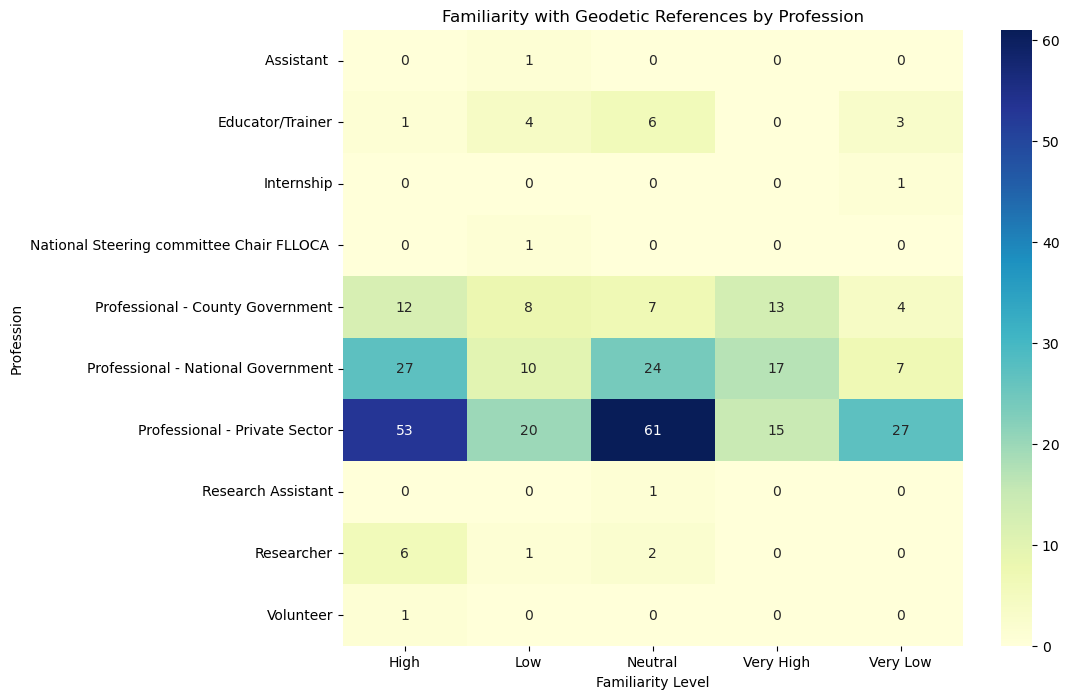

In [81]:

pivot_data = geod_cols.pivot_table(index='Q3', columns='Q8', aggfunc='size', fill_value=0)

# The heatmap
plt.figure(figsize=(10, 8)) 
sns.heatmap(pivot_data, annot=True, fmt="d", cmap="YlGnBu") 
plt.title("Familiarity with Geodetic References by Profession")
plt.xlabel("Familiarity Level")
plt.ylabel("Profession")
plt.show()

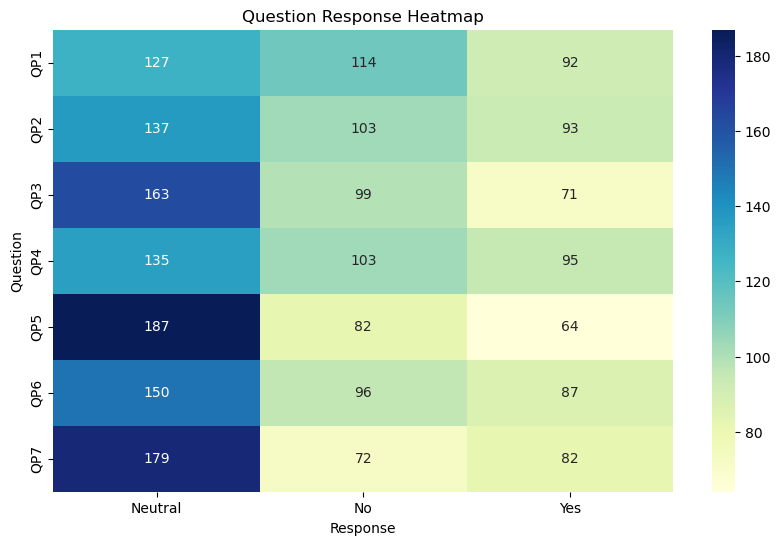

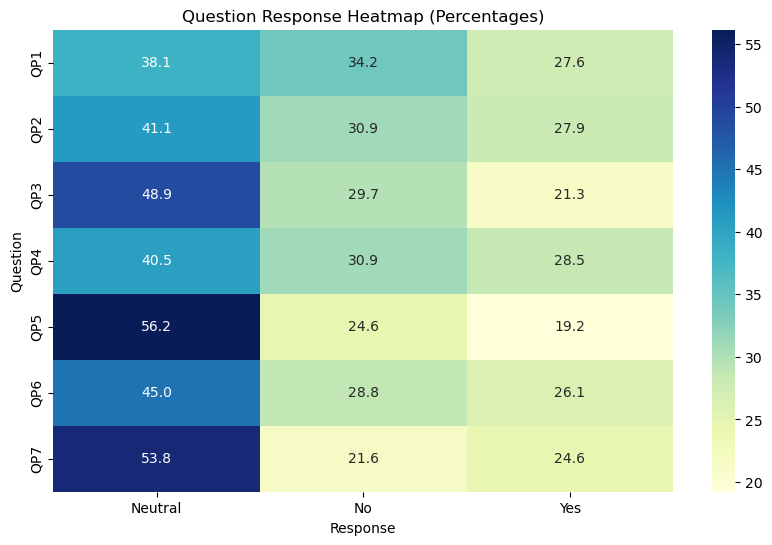

In [82]:
# Your data (replace with your actual data if different)
gender_data = {'Male': 245, 'Female': 88}
qp_data = {
    'QP1': {'Neutral': 127, 'No': 114, 'Yes': 92},
    'QP2': {'Neutral': 137, 'No': 103, 'Yes': 93},
    'QP3': {'Neutral': 163, 'No': 99, 'Yes': 71},
    'QP4': {'Neutral': 135, 'No': 103, 'Yes': 95},
    'QP5': {'Neutral': 187, 'No': 82, 'Yes': 64},
    'QP6': {'Neutral': 150, 'No': 96, 'Yes': 87},
    'QP7': {'Neutral': 179, 'Yes': 82, 'No': 72},  # Corrected order here
}

# Create a DataFrame for the heatmap
data = []
for qp, responses in qp_data.items():
    for response, count in responses.items():
        data.append({'Question': qp, 'Response': response, 'Count': count})

df = pd.DataFrame(data)

# Pivot the table for the heatmap
heatmap_data = df.pivot(index='Question', columns='Response', values='Count')

# Create the heatmap
plt.figure(figsize=(10, 6))  # Adjust figure size as needed
sns.heatmap(heatmap_data, annot=True, cmap="YlGnBu", fmt="d") #fmt = "d" ensures the annotation is an integer.
plt.title("Question Response Heatmap")
plt.xlabel("Response")
plt.ylabel("Question")
plt.show()


# --- Optional: Heatmap showing percentages within each question ---

heatmap_data_percentage = heatmap_data.apply(lambda x: (x / x.sum()) * 100, axis=1)

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data_percentage, annot=True, cmap="YlGnBu", fmt=".1f") #fmt = ".1f" to display one decimal place.
plt.title("Question Response Heatmap (Percentages)")
plt.xlabel("Response")
plt.ylabel("Question")
plt.show()





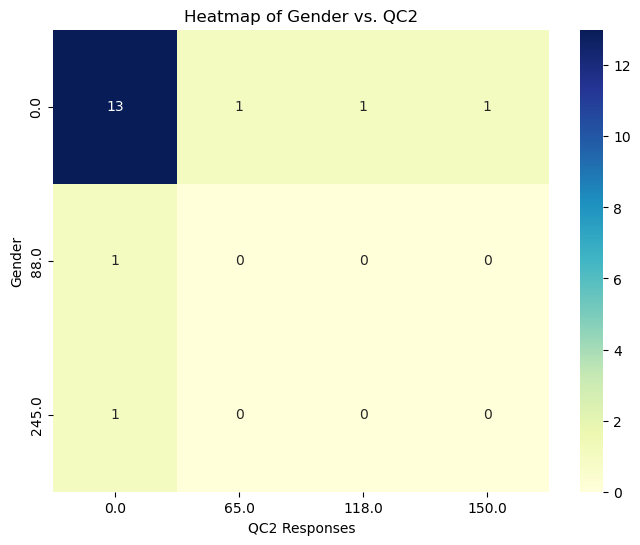

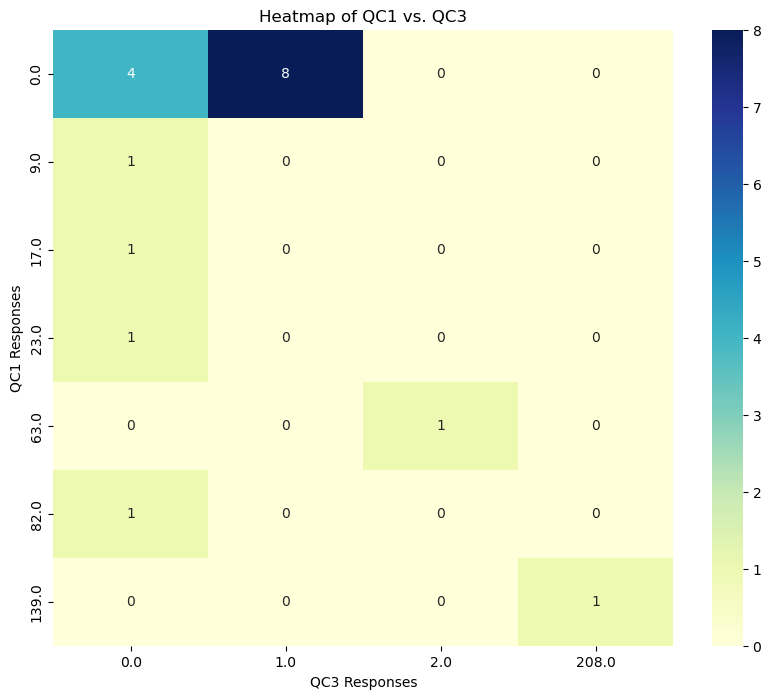

In [83]:
# Your original data (replace with your actual data if different)
gender_data = {'Male': 245, 'Female': 88}
qc1_data = {'Unknown': 139, 'Good': 82, 'Neutral': 63, 'Very Good': 17, 'Poor': 23, 'Very Poor': 9}
qc2_data = {'Unknown': 150, 'Yes': 118, 'No': 65}
qc3_data = {'Unknown': 208, 'Neutral': 2, 'Use of new technology (GPS)': 1, 'Emerging technologies easier': 1, 'Current approach ensures authentication': 1, 'Gradually headed right direction': 1, 'Manual system in Kenya': 1, 'Advancement in tech': 1, 'Following Survey Act': 1, 'Not suitable approach': 1}

# Convert to Series
gender = pd.Series(gender_data)
qc1 = pd.Series(qc1_data)
qc2 = pd.Series(qc2_data)
qc3 = pd.Series(qc3_data)

# Create DataFrame
df = pd.DataFrame({'Gender': gender, 'QC1': qc1, 'QC2': qc2, 'QC3': qc3}).fillna(0)

# 1. Cross-tabulation: Gender vs. QC2
cross_tab_gender_qc2 = pd.crosstab(df['Gender'], df['QC2'])

# 2. Heatmap: Gender vs. QC2
plt.figure(figsize=(8, 6))  # Adjust figure size as needed
sns.heatmap(cross_tab_gender_qc2, annot=True, cmap="YlGnBu", fmt="d")
plt.title("Heatmap of Gender vs. QC2")
plt.xlabel("QC2 Responses")
plt.ylabel("Gender")
plt.show()



# 3. Cross-tabulation: QC1 vs. QC3 (Example - adapt as needed)
cross_tab_qc1_qc3 = pd.crosstab(df['QC1'], df['QC3'])

# 4. Heatmap: QC1 vs. QC3
plt.figure(figsize=(10, 8)) # Adjust figure size as needed
sns.heatmap(cross_tab_qc1_qc3, annot=True, cmap="YlGnBu", fmt="d")
plt.title("Heatmap of QC1 vs. QC3")
plt.xlabel("QC3 Responses")
plt.ylabel("QC1 Responses")
plt.show()

# ... (You can create other cross-tabulations and heatmaps as needed)

### 4.2.1 Conclusions for the Heatmap
#### 1. Understanding the Professional Profile of Participants:

* Private Sector Dominance: The high representation of private sector professionals in the survey underscores their significant role and engagement within the land sector. (Relates to: Identify the demographic and professional background...)
* Diverse Professional Backgrounds: The inclusion of professionals from various sectors (private, county government, national government, research, etc.) highlights the survey's reach across diverse land sector expertise. (Relates to: Identify the demographic and professional background... & Assess the distribution of expertise...)
* Range of Expertise: The varying familiarity levels observed across professions likely reflect the diverse roles and responsibilities related to geodetic reference systems within the land sector. (Relates to: Assess the distribution of expertise...)
#### 2. Assessing the Current Status and Utilization of Kenya’s Geodetic Reference System:

* Private Sector Proficiency: The concentration of "High" and "Very High" familiarity within the private sector suggests a strong understanding and utilization of geodetic reference systems in this sector. (Relates to: Evaluate professionals’ familiarity...)
* Potential Disparities in Access and Training: The broader distribution of familiarity levels in the county and national government sectors may indicate varying levels of access to training and resources related to the geodetic reference system. Further research is needed to understand these differences. (Relates to: Measure the accessibility, adequacy... & Identify gaps...)
* Targeted Support for Specific Sectors: The distinct patterns observed across sectors suggest a need for tailored training and support programs to ensure consistent and effective utilization of the geodetic reference system across all professional groups. (Relates to: Identify gaps and suggest improvements...)
* Limited Data for Some Professions: The small sample sizes for certain professions (e.g., researchers, educators, interns) limit the ability to draw robust conclusions about their familiarity and utilization of the geodetic reference system. Further data collection is needed to address this gap. (Relates to: Evaluate professionals’ familiarity... & Measure the accessibility...)

#### Overall Summary (Combined):

The survey reveals a strong engagement of the private sector with geodetic reference systems, particularly at higher familiarity levels.  While other sectors are represented, there may be disparities in access to training and resources, especially for county and national government professionals.  Targeted support and further research are needed to ensure consistent and effective utilization of the geodetic reference system across all land sector professionals, including those groups with limited data in the current survey.

## 4.3 Confusion Matrix data representation

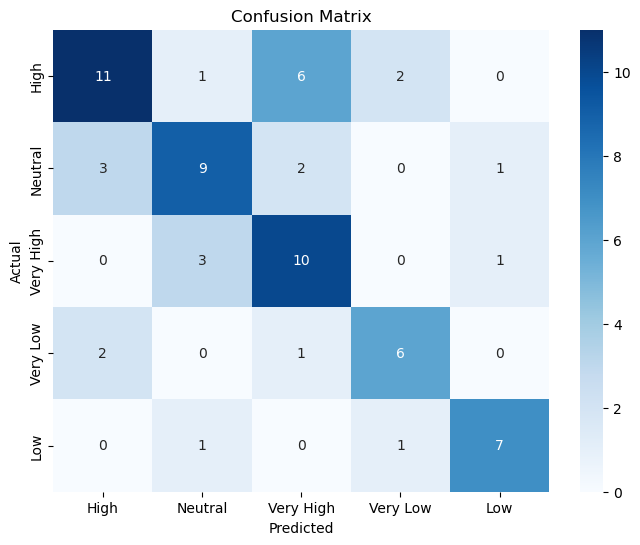

              precision    recall  f1-score   support

        High       0.69      0.55      0.61        20
         Low       0.64      0.60      0.62        15
     Neutral       0.53      0.71      0.61        14
   Very High       0.67      0.67      0.67         9
    Very Low       0.78      0.78      0.78         9

    accuracy                           0.64        67
   macro avg       0.66      0.66      0.66        67
weighted avg       0.65      0.64      0.64        67



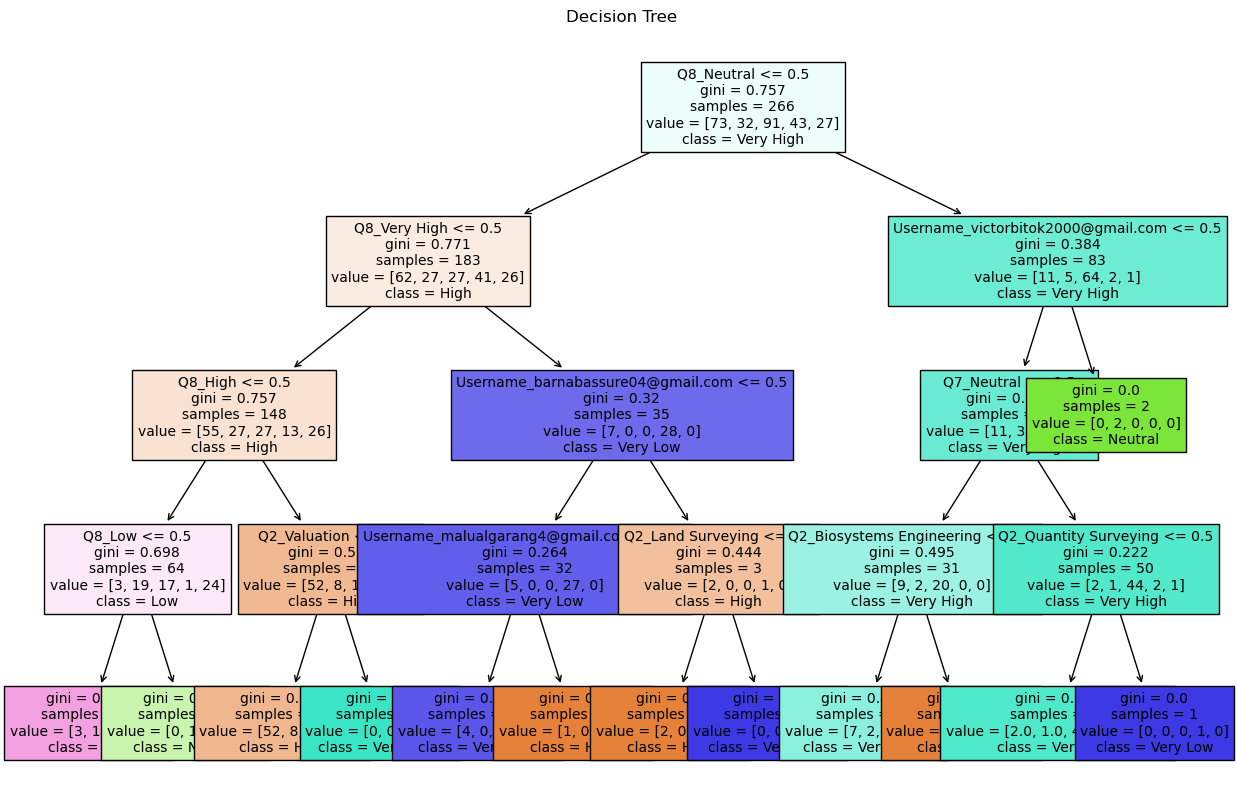

In [84]:
X = geod_cols.drop('Q9', axis=1)  # Features (all columns except the target)
y = geod_cols['Q9']  # Target variable

# Convert categorical features to numerical using one-hot encoding
X = pd.get_dummies(X) # One-hot encode all categorical columns

# 2. Split Data into Training and Testing Sets:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)  # 80% train, 20% test

# 3. Train the Decision Tree Model:
clf = DecisionTreeClassifier(random_state=42, max_depth=4)  # Create the classifier
clf.fit(X_train, y_train)  # Train the classifier

# 4. Make Predictions on the Test Set:
y_pred = clf.predict(X_test)

# 5. Evaluate the Model:

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=y.unique(), yticklabels=y.unique()) # Add labels
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


print(classification_report(y_test, y_pred))


plt.figure(figsize=(15, 10))  # Adjust figure size as needed
tree.plot_tree(clf, filled=True, feature_names=X.columns, class_names=y.unique(), fontsize=10) # Add feature and class names
plt.title("Decision Tree")
plt.show()

In [85]:

cross_tab = pd.crosstab(cada_cols['Gender'], cada_cols['QC2'])
print(cross_tab)

# Example: Cross-tabulation of QC1 and QC3
cross_tab2 = pd.crosstab(cada_cols['QC1'], cada_cols['QC3'])
print(cross_tab2)

QC2     No  Unknown  Yes
Gender                  
Female  12       45   31
Male    53      105   87
QC3        1.Using of old pland oand survey are still being used \n2.Mix of general and fixed boundaries   \
QC1                                                                                                         
Good                                                       0                                                
Neutral                                                    0                                                
Poor                                                       0                                                
Unknown                                                    0                                                
Very Good                                                  0                                                
Very Poor                                                  1                                                

QC3        Accessible and a

### 4.3.1 Conclusions of the above
#### 1. Understanding the Professional Profile of Participants:

* Influence of Familiarity (Q8): The decision tree highlights familiarity with geodetic references (Q8) as a key factor differentiating professional profiles. This suggests that familiarity levels may be linked to specific roles, responsibilities, or areas of specialization within the land sector. (Relates to: Assess the distribution of expertise...)
* Potential Links Between Profession and Familiarity: The decision tree's branches suggest potential connections between profession (e.g., private sector) and familiarity levels (e.g., "High"). Further investigation could explore these relationships to understand how different professional backgrounds influence engagement with geodetic reference systems. (Relates to: Evaluate the level of experience and professional practice... & Assess the distribution of expertise...)
* Role of Other Factors (Q7, Gender): The decision tree indicates that other factors, such as Q7 (likely a survey question) and gender, may also play a role in shaping professionals' familiarity with geodetic references, particularly at lower familiarity levels. Further analysis is needed to understand the nature of these influences. (Relates to: Identify the demographic and professional background...)
#### 2. Assessing the Current Status and Utilization of Kenya’s Geodetic Reference System:

* Varying Levels of Understanding: The confusion matrix and decision tree both demonstrate a range of familiarity levels among professionals, suggesting varying degrees of understanding and utilization of the geodetic reference system. (Relates to: Evaluate professionals’ familiarity...)
* Areas for Improvement: The confusion matrix highlights potential areas for improvement in the clarity or accessibility of information about the geodetic reference system, particularly given the confusion between "High," "Very Low," and "Low" categories. This suggests a need for targeted training or resources to address these specific areas of misunderstanding. (Relates to: Identify gaps and suggest improvements...)
* Targeted Training and Resources: The decision tree's identification of specific profiles (e.g., users like "kawirasharon996") associated with lower familiarity could inform the development of targeted training and resources to improve understanding and utilization within specific professional groups. (Relates to: Identify gaps and suggest improvements...)
* Need for Further Research: The small sample sizes at some decision tree leaf nodes highlight the need for further research to gather more data and draw more robust conclusions about specific professional groups. (Relates to: Measure the accessibility, adequacy...)

#### Overall Summary (Combined):

The analysis of the confusion matrix and decision tree reveals a complex landscape of familiarity with geodetic references among land sector professionals.  While familiarity (Q8) is a clear differentiating factor, other factors like profession, Q7, and gender also appear to play a role.  The findings suggest a need for targeted training and resources to address areas of confusion and improve overall understanding and utilization of the geodetic reference system, particularly for specific professional groups and those exhibiting lower familiarity.  Further research with larger sample sizes is recommended to strengthen these conclusions.

# 5. CONCLUSIONS AND RECOMMENDATIONS

## 5.1 Conclusions

This survey of Kenyan land sector professionals reveals a complex interplay between professional background, familiarity with geodetic reference systems, and potential gaps in knowledge and utilization.  The private sector demonstrates a strong engagement and generally high familiarity with geodetic references, while other sectors, particularly county and national government, show a broader range of familiarity levels, potentially indicating disparities in access to training and resources.  Analysis of survey data, including visualizations and machine learning models, confirms familiarity as a key differentiating factor among professionals and suggests that other factors like profession, specific survey questions (Q7), and gender also play a role.  These findings underscore the need for targeted interventions, including training programs and resource development, tailored to the specific needs of different professional groups. Further research with larger sample sizes is recommended to solidify these conclusions and provide a more comprehensive understanding of the landscape.


## 5.2 Recommendations

Develop Targeted Training Programs: Based on the identified gaps in familiarity, create tailored training programs for specific professional groups (e.g., county government professionals, those with lower familiarity levels). These programs should focus on practical application of the Kenyan Geodetic Reference Frame, addressing common areas of confusion, and providing hands-on experience with relevant tools and technologies.  Consider offering tiered training options, from basic awareness to advanced technical skills, to cater to different levels of expertise.

Improve Access to Resources and Support: Enhance access to information and resources related to the KGRS. This could include developing online tutorials, creating user-friendly guides, establishing help desks or support networks, and ensuring easy access to reference stations and data.  Consider partnering with professional organizations and educational institutions to disseminate information and provide ongoing support.

Conduct Further Research with Larger Samples:  Address the data limitations for certain professional groups by conducting further research with larger and more representative samples. This will allow for more robust conclusions about the specific needs and challenges faced by different segments of the land sector workforce.  Explore qualitative research methods, such as interviews or focus groups, to gain deeper insights into the barriers to utilization and gather feedback on potential solutions.

Promote Awareness and Advocacy:  Launch awareness campaigns to highlight the importance of the KGRS for efficient and accurate land management. Target these campaigns towards both professionals and the general public, emphasizing the benefits of using a standardized geodetic reference frame for various land-related activities. Advocate for policies and investments that support the long-term sustainability and accessibility of the KGRS infrastructure.  This could include working with government agencies and professional bodies to integrate KGRS knowledge into professional licensing requirements or continuing education programs.
